In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.config import PROCESSED_DATA_DIR
from src.data_utils import read_panel
from src.backtest import (
    count_violations, 
    kupiec_test,
    christoffersen_test,
    diebold_mariano,
    kupiec_summary,
    christoffersen_summary,
)

us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.csv")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.csv")["return"]

us_static_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_var_static_95.csv", index_col = 0, parse_dates = True)
us_static_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_var_static_99.csv", index_col = 0, parse_dates = True)
india_static_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_var_static_95.csv", index_col = 0, parse_dates = True)
india_static_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_var_static_99.csv", index_col = 0, parse_dates = True)

us_garch_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_garch_var_95.csv", index_col = 0, parse_dates = True)
us_garch_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_garch_var_99.csv", index_col = 0, parse_dates = True)
india_garch_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_garch_var_95.csv", index_col = 0, parse_dates = True)
india_garch_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_garch_var_99.csv", index_col = 0, parse_dates = True)

us_gjr_95 = pd.read_csv(PROCESSED_DATA_DIR / "us_gjr_var_95.csv", index_col = 0, parse_dates = True)
us_gjr_99 = pd.read_csv(PROCESSED_DATA_DIR / "us_gjr_var_99.csv", index_col = 0, parse_dates = True)
india_gjr_95 = pd.read_csv(PROCESSED_DATA_DIR / "india_gjr_var_95.csv", index_col = 0, parse_dates = True)
india_gjr_99 = pd.read_csv(PROCESSED_DATA_DIR / "india_gjr_var_99.csv", index_col = 0, parse_dates = True)

print('Done')


Done


In [2]:
# US 95%
us_v_hist_95 = count_violations(us, us_static_95["historical_var"])
us_v_norm_95 = count_violations(us, us_static_95["normal_var"])
us_v_t_95 = count_violations(us, us_static_95["student_t_var"])
us_v_mc_95 = count_violations(us, us_static_95["monte_carlo_var"])
us_v_garch_95 = count_violations(us, us_garch_95["var"])
us_v_gjr_95 = count_violations(us, us_gjr_95["var"])

# US 99%
us_v_hist_99 = count_violations(us, us_static_99["historical_var"])
us_v_norm_99 = count_violations(us, us_static_99["normal_var"])
us_v_t_99 = count_violations(us, us_static_99["student_t_var"])
us_v_mc_99 = count_violations(us, us_static_99["monte_carlo_var"])
us_v_garch_99 = count_violations(us, us_garch_99["var"])
us_v_gjr_99 = count_violations(us, us_gjr_99["var"])

# India 95%
india_v_hist_95 = count_violations(india, india_static_95["historical_var"])
india_v_norm_95 = count_violations(india, india_static_95["normal_var"])
india_v_t_95 = count_violations(india, india_static_95["student_t_var"])
india_v_mc_95 = count_violations(india, india_static_95["monte_carlo_var"])
india_v_garch_95 = count_violations(india, india_garch_95["var"])
india_v_gjr_95 = count_violations(india, india_gjr_95["var"])

# India 99%
india_v_hist_99 = count_violations(india, india_static_99["historical_var"])
india_v_norm_99 = count_violations(india, india_static_99["normal_var"])
india_v_t_99 = count_violations(india, india_static_99["student_t_var"])
india_v_mc_99 = count_violations(india, india_static_99["monte_carlo_var"])
india_v_garch_99 = count_violations(india, india_garch_99["var"])
india_v_gjr_99 = count_violations(india, india_gjr_99["var"])

print("Done.")

Done.


In [3]:
us_viols_95 = {
    "Historical": us_v_hist_95, "Normal": us_v_norm_95, "Student-t": us_v_t_95,
    "Monte Carlo": us_v_mc_95, "GARCH": us_v_garch_95, "GJR-GARCH": us_v_gjr_95,
}
us_viols_99 = {
    "Historical": us_v_hist_99, "Normal": us_v_norm_99, "Student-t": us_v_t_99,
    "Monte Carlo": us_v_mc_99, "GARCH": us_v_garch_99, "GJR-GARCH": us_v_gjr_99,
}
india_viols_95 = {
    "Historical": india_v_hist_95, "Normal": india_v_norm_95, "Student-t": india_v_t_95,
    "Monte Carlo": india_v_mc_95, "GARCH": india_v_garch_95, "GJR-GARCH": india_v_gjr_95,
}
india_viols_99 = {
    "Historical": india_v_hist_99, "Normal": india_v_norm_99, "Student-t": india_v_t_99,
    "Monte Carlo": india_v_mc_99, "GARCH": india_v_garch_99, "GJR-GARCH": india_v_gjr_99,
}

kupiec_table = pd.concat([
    kupiec_summary(us_viols_95, 0.05, "US", "95%"),
    kupiec_summary(us_viols_99, 0.01, "US", "99%"),
    kupiec_summary(india_viols_95, 0.05, "India", "95%"),
    kupiec_summary(india_viols_99, 0.01, "India", "99%"),    
], ignore_index = True)

print(kupiec_table.to_string(index = False))

Market Level      Method  Expected  Actual  Rate %  Kupiec p-val Pass
    US   95%  Historical       188     195    5.17        0.6317 PASS
    US   95%      Normal       188     195    5.17        0.6317 PASS
    US   95%   Student-t       188     224    5.94        0.0100 FAIL
    US   95% Monte Carlo       188     191    5.06        0.8550 PASS
    US   95%       GARCH       176     187    5.31        0.4061 PASS
    US   95%   GJR-GARCH       176     199    5.65        0.0833 PASS
    US   99%  Historical        37      62    1.64        0.0003 FAIL
    US   99%      Normal        37      95    2.52        0.0000 FAIL
    US   99%   Student-t        37      70    1.86        0.0000 FAIL
    US   99% Monte Carlo        37      54    1.43        0.0123 FAIL
    US   99%       GARCH        35      92    2.61        0.0000 FAIL
    US   99%   GJR-GARCH        35      99    2.81        0.0000 FAIL
 India   95%  Historical       184     192    5.19        0.5917 PASS
 India   95%      No

In [4]:
christoffersen_table = pd.concat([
    christoffersen_summary(us_viols_95, "US", "95%"),
    christoffersen_summary(us_viols_99, "US", "99%"),
    christoffersen_summary(india_viols_95, "India", "95%"),
    christoffersen_summary(india_viols_99, "India", "99%"),    
], ignore_index = True)

print(christoffersen_table.to_string(index = False))

Market Level      Method  Christ p-val Pass
    US   95%  Historical        0.0000 FAIL
    US   95%      Normal        0.0000 FAIL
    US   95%   Student-t        0.0000 FAIL
    US   95% Monte Carlo        0.0000 FAIL
    US   95%       GARCH        0.0010 FAIL
    US   95%   GJR-GARCH        0.0000 FAIL
    US   99%  Historical        0.0000 FAIL
    US   99%      Normal        0.0000 FAIL
    US   99%   Student-t        0.0000 FAIL
    US   99% Monte Carlo        0.0001 FAIL
    US   99%       GARCH        0.0001 FAIL
    US   99%   GJR-GARCH        0.0001 FAIL
 India   95%  Historical        0.0066 FAIL
 India   95%      Normal        0.0225 FAIL
 India   95%   Student-t        0.0007 FAIL
 India   95% Monte Carlo        0.0036 FAIL
 India   95%       GARCH        0.0014 FAIL
 India   95%   GJR-GARCH        0.0032 FAIL
 India   99%  Historical        0.2445 PASS
 India   99%      Normal        0.0006 FAIL
 India   99%   Student-t        0.9519 PASS
 India   99% Monte Carlo        

In [9]:
combined = kupiec_table.merge(
    christoffersen_table[["Market", "Level", "Method", "Christ p-val", "Pass"]].rename(columns = {"Pass": "Christ Pass"}),
    on = ["Market", "Level", "Method"]
)
combined = combined.rename(columns = {"Pass": "Kupiec Pass"})

print(combined.to_string(index = False))

Market Level      Method  Expected  Actual  Rate %  Kupiec p-val Kupiec Pass  Christ p-val Christ Pass
    US   95%  Historical       188     195    5.17        0.6317        PASS        0.0000        FAIL
    US   95%      Normal       188     195    5.17        0.6317        PASS        0.0000        FAIL
    US   95%   Student-t       188     224    5.94        0.0100        FAIL        0.0000        FAIL
    US   95% Monte Carlo       188     191    5.06        0.8550        PASS        0.0000        FAIL
    US   95%       GARCH       176     187    5.31        0.4061        PASS        0.0010        FAIL
    US   95%   GJR-GARCH       176     199    5.65        0.0833        PASS        0.0000        FAIL
    US   99%  Historical        37      62    1.64        0.0003        FAIL        0.0000        FAIL
    US   99%      Normal        37      95    2.52        0.0000        FAIL        0.0000        FAIL
    US   99%   Student-t        37      70    1.86        0.0000        F

In [10]:
print("US 95% comparisons:")
dm, p = diebold_mariano(us, us_garch_95["var"], us_gjr_95["var"])
print(f"  GARCH vs. GJR-GARCH:    DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(us, us_garch_95["var"], us_static_95["historical_var"])
print(f"  GARCH vs. Historical:   DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(us, us_static_95["historical_var"], us_static_95["normal_var"])
print(f"  Historical vs. Normal:  DM={dm:.3f}, p={p:.4f}")

print("\nIndia 95% comparisons:")
dm, p = diebold_mariano(india, india_garch_95["var"], india_gjr_95["var"])
print(f"  GARCH vs. GJR-GARCH:    DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(india, india_garch_95["var"], india_static_95["historical_var"])
print(f"  GARCH vs. Historical:   DM={dm:.3f}, p={p:.4f}")
dm, p = diebold_mariano(india, india_static_95["historical_var"], india_static_95["normal_var"])
print(f"  Historical vs. Normal:  DM={dm:.3f}, p={p:.4f}")

US 95% comparisons:
  GARCH vs. GJR-GARCH:    DM=-1.426, p=0.1540
  GARCH vs. Historical:   DM=-1.340, p=0.1803
  Historical vs. Normal:  DM=-9.524, p=0.0000

India 95% comparisons:
  GARCH vs. GJR-GARCH:    DM=-3.460, p=0.0005
  GARCH vs. Historical:   DM=2.473, p=0.0134
  Historical vs. Normal:  DM=-7.945, p=0.0000


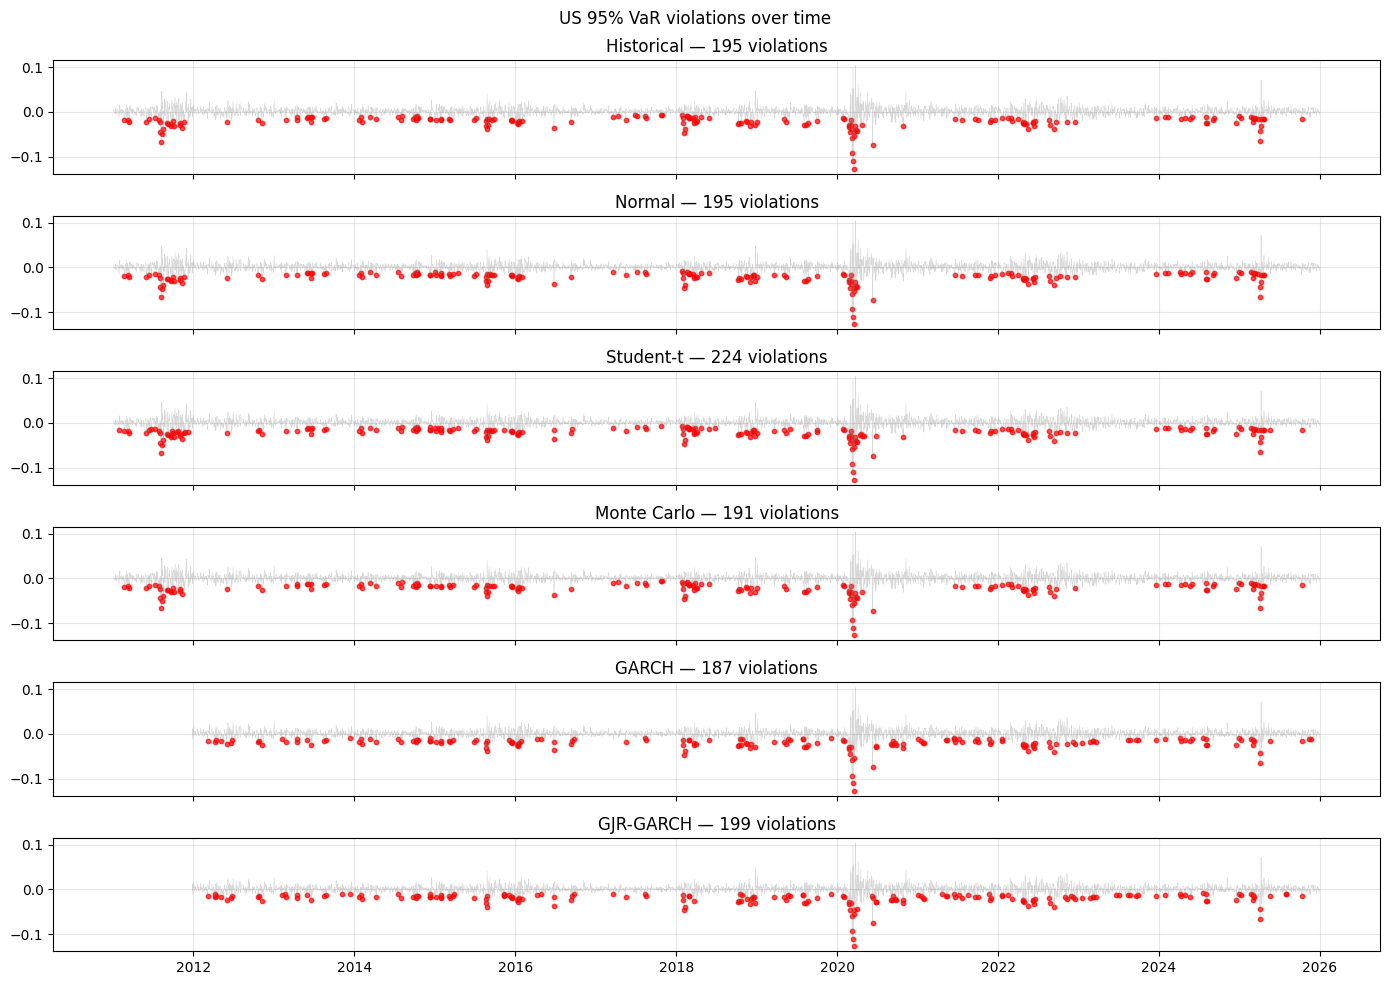

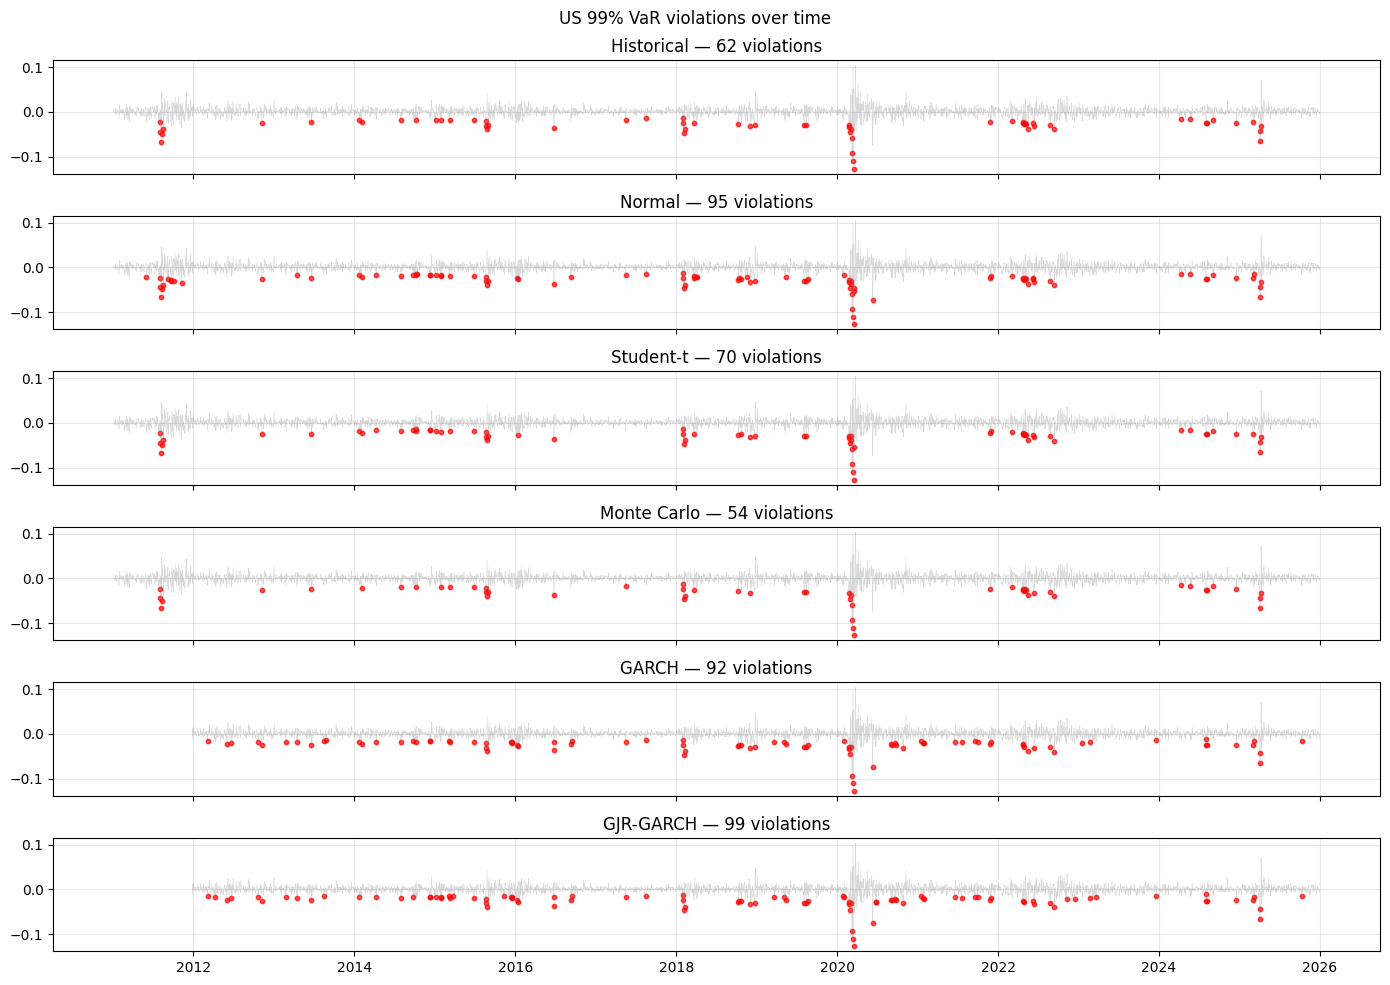

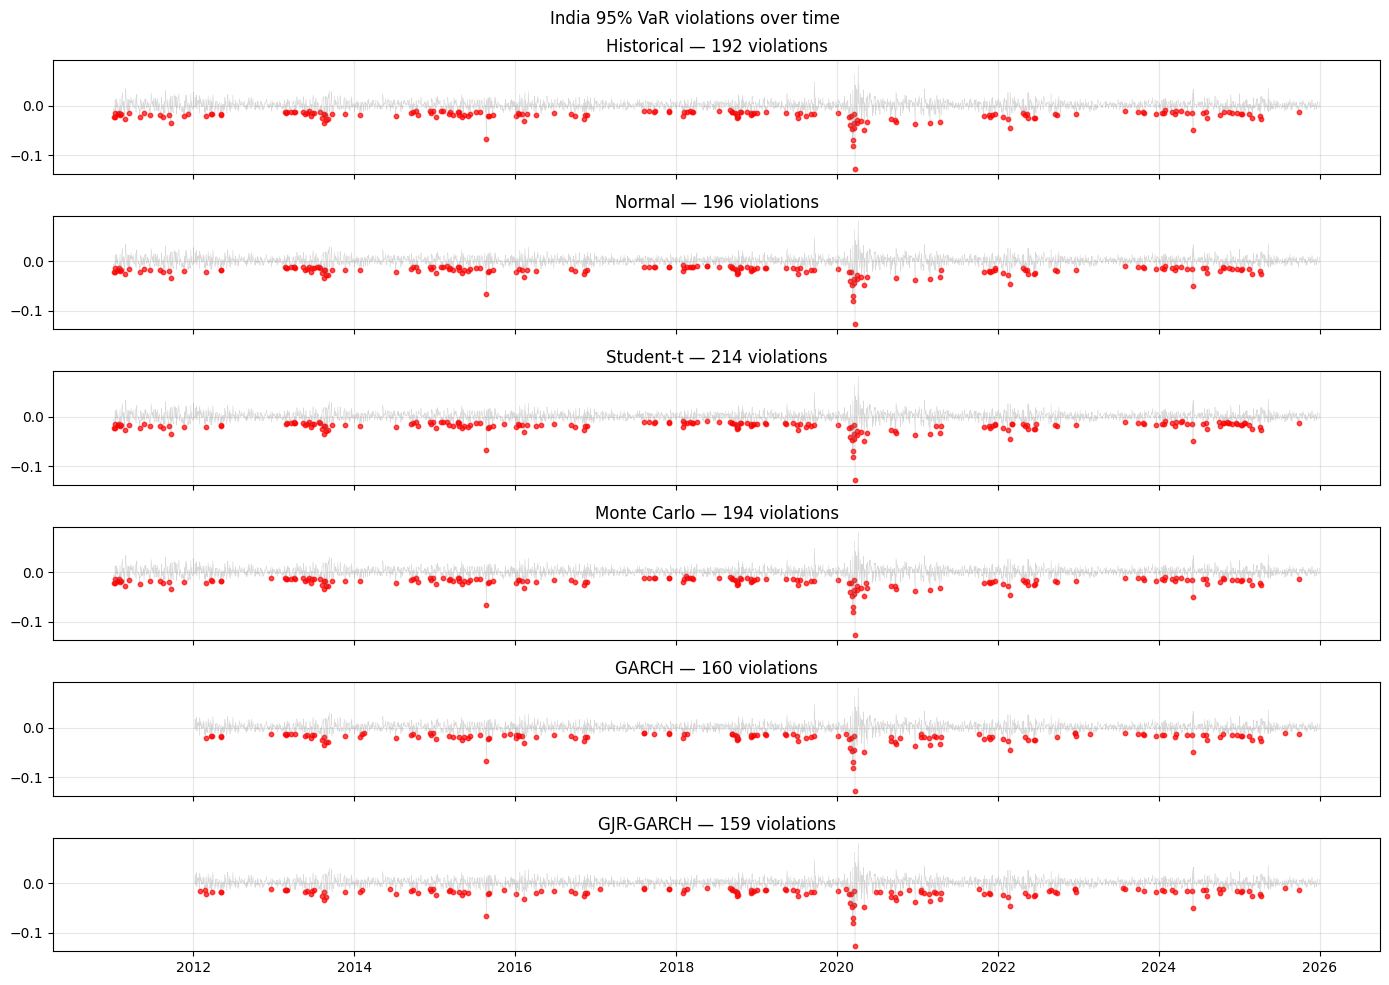

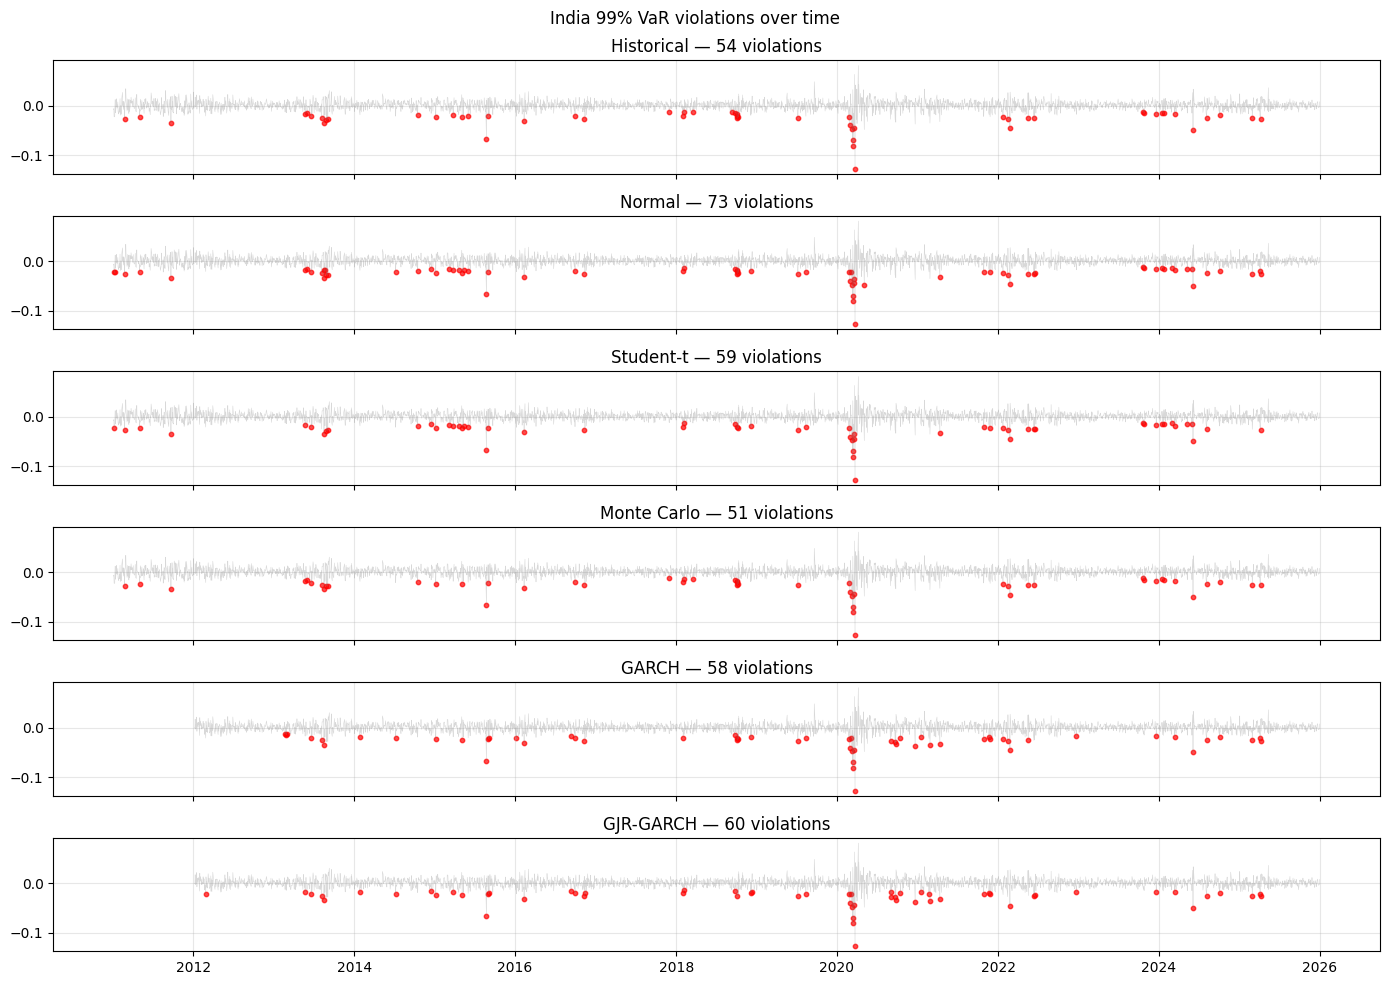

In [7]:
def plot_violation_timeline(returns, viol_dict, market, level):
    fig, axes = plt.subplots(len(viol_dict), 1, figsize=(14, 10), sharex=True)
    for ax, (method, v) in zip(axes, viol_dict.items()):  
        aligned_returns = returns.loc[v.index]
        ax.plot(aligned_returns.index, aligned_returns, color="gray", alpha=0.3, linewidth=0.4)
        viol_dates = v[v == 1].index
        ax.scatter(viol_dates, aligned_returns.loc[viol_dates], color="red", s=10, alpha=0.7)
        ax.set_title(f"{method} — {v.sum()} violations")
        ax.grid(alpha=0.3)
    plt.suptitle(f"{market} {level} VaR violations over time")
    plt.tight_layout()
    plt.show()


plot_violation_timeline(us, us_viols_95, "US", "95%")
plot_violation_timeline(us, us_viols_99, "US", "99%")
plot_violation_timeline(india, india_viols_95, "India", "95%")
plot_violation_timeline(india, india_viols_99, "India", "99%")

In [11]:
combined.to_csv(PROCESSED_DATA_DIR / "backtest_summary.csv", index=False)
print("Saved.")

Saved.
